/var/folders/gy/d7p0zrqx7l3f7dwplj0g_b040000gn/T/ipykernel_88395/3346687259.py:60: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


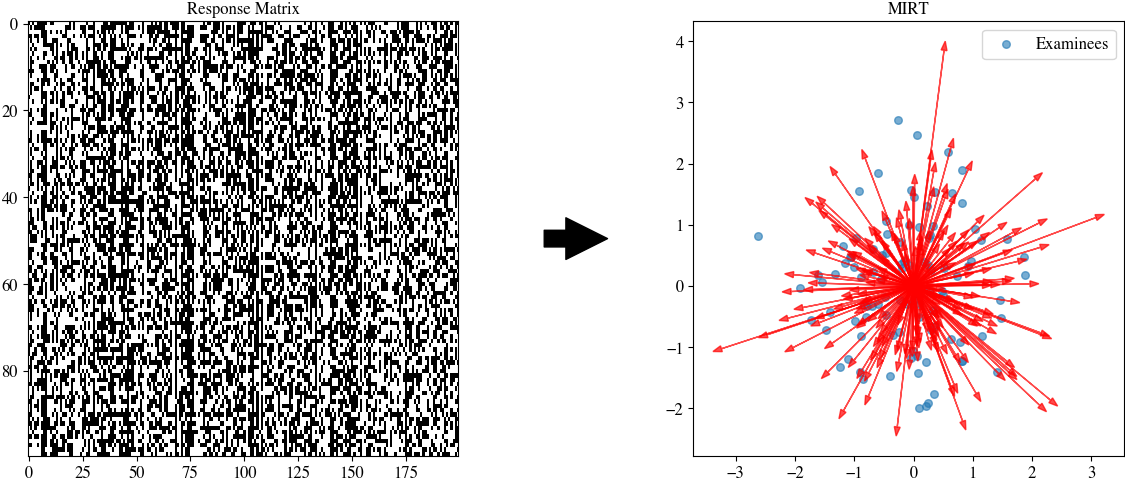

In [15]:
import numpy as np
import sys
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
sys.path.append('..') 
import style
plt.rcParams.update(style.rcparams)

# ----------------------------
# 1. Synthetic response matrix
# ----------------------------
np.random.seed(42)
n_examinees, n_items, k_dim = 100, 200, 2

# Generate synthetic latent traits and item parameters
theta = np.random.normal(size=(n_examinees, k_dim))  # abilities
a = np.random.normal(size=(n_items, k_dim))          # discriminations
b = np.random.normal(size=n_items)                   # difficulties

# Generate responses
def irt_prob(theta, a, b):
    return 1 / (1 + np.exp(-(theta @ a.T - b)))

p_matrix = irt_prob(theta, a, b)
response_matrix = (np.random.rand(*p_matrix.shape) < p_matrix).astype(int)

# ----------------------------
# 2. Visualization
# ----------------------------
fig, axes = plt.subplots(1, 3, figsize=(14.5, 6), gridspec_kw={'width_ratios':[1,0.2,1]})

# Left panel: Response matrix
axes[0].imshow(response_matrix, aspect='auto', cmap='Greys', interpolation='nearest')
axes[0].set_title("Response Matrix")
# axes[0].set_xlabel("Items")
# axes[0].set_ylabel("Examinees")

# Middle panel: Arrow as conceptual transformation
arrow = FancyArrowPatch((0.1,0.5), (0.9,0.5), 
                        connectionstyle="arc3,rad=0.0", 
                        arrowstyle='simple',
                        mutation_scale=60, color="black")
axes[1].add_patch(arrow)
axes[1].axis("off")

# Right panel: Latent embedding
# Examinees as points
axes[2].scatter(theta[:,0], theta[:,1], alpha=0.6, s=30, label="Examinees")

# Items as arrows
for i in range(n_items):
    axes[2].arrow(0, 0, a[i,0], a[i,1], head_width=0.1, alpha=0.7, color="red")
axes[2].set_title("MIRT")
# axes[2].set_xlabel("Factor 1")
# axes[2].set_ylabel("Factor 2")
axes[2].legend()

plt.savefig('test.svg')

plt.tight_layout()
plt.show()


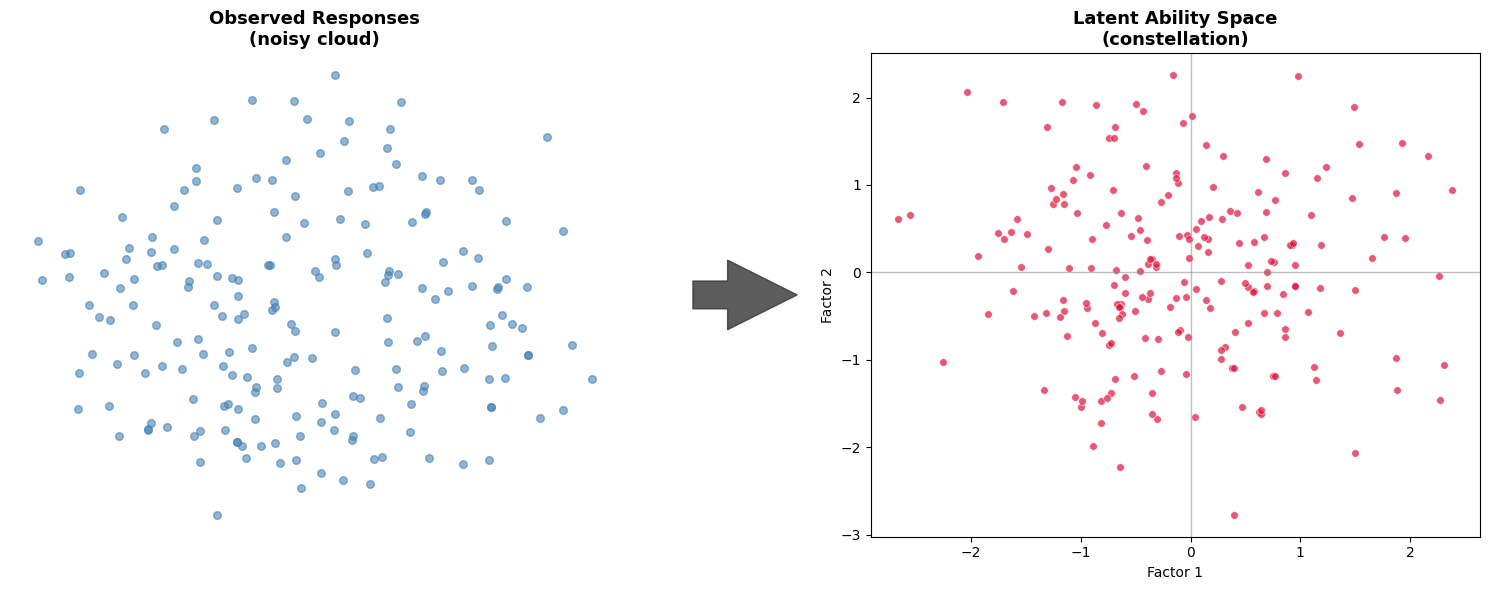

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from sklearn.decomposition import PCA

# ----------------------------
# Synthetic dataset
# ----------------------------
np.random.seed(0)
n_examinees, n_items, k_dim = 200, 20, 2

theta = np.random.normal(size=(n_examinees, k_dim))
a = np.random.normal(size=(n_items, k_dim))
b = np.random.normal(size=n_items)

def irt_prob(theta, a, b):
    return 1 / (1 + np.exp(-(theta @ a.T - b)))

p = irt_prob(theta, a, b)
responses = (np.random.rand(*p.shape) < p).astype(int)

# Pre-MIRT projection (noisy view)
pca = PCA(n_components=2)
pre_coords = pca.fit_transform(responses)

# Post-MIRT (true latent abilities)
post_coords = theta

# ----------------------------
# Visualization
# ----------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 6), gridspec_kw={'width_ratios':[1,0.2,1]})

# Before: noisy cloud
axes[0].scatter(pre_coords[:,0], pre_coords[:,1], 
                c="steelblue", alpha=0.6, s=30)
axes[0].set_title("Observed Responses\n(noisy cloud)", fontsize=13, weight="bold")
axes[0].axis("off")

# Arrow
arrow = FancyArrowPatch((0.05,0.5), (0.95,0.5),
                        connectionstyle="arc3,rad=0.0",
                        arrowstyle='simple',
                        mutation_scale=100, color="#333", alpha=0.8)
axes[1].add_patch(arrow)
axes[1].axis("off")

# After: structured latent space
axes[2].scatter(post_coords[:,0], post_coords[:,1],
                c="crimson", alpha=0.7, s=30, edgecolor="white", linewidth=0.5)
axes[2].axhline(0, color="gray", lw=1, alpha=0.5)
axes[2].axvline(0, color="gray", lw=1, alpha=0.5)
axes[2].set_title("Latent Ability Space\n(constellation)", fontsize=13, weight="bold")
axes[2].set_xlabel("Factor 1")
axes[2].set_ylabel("Factor 2")

plt.tight_layout()
plt.show()


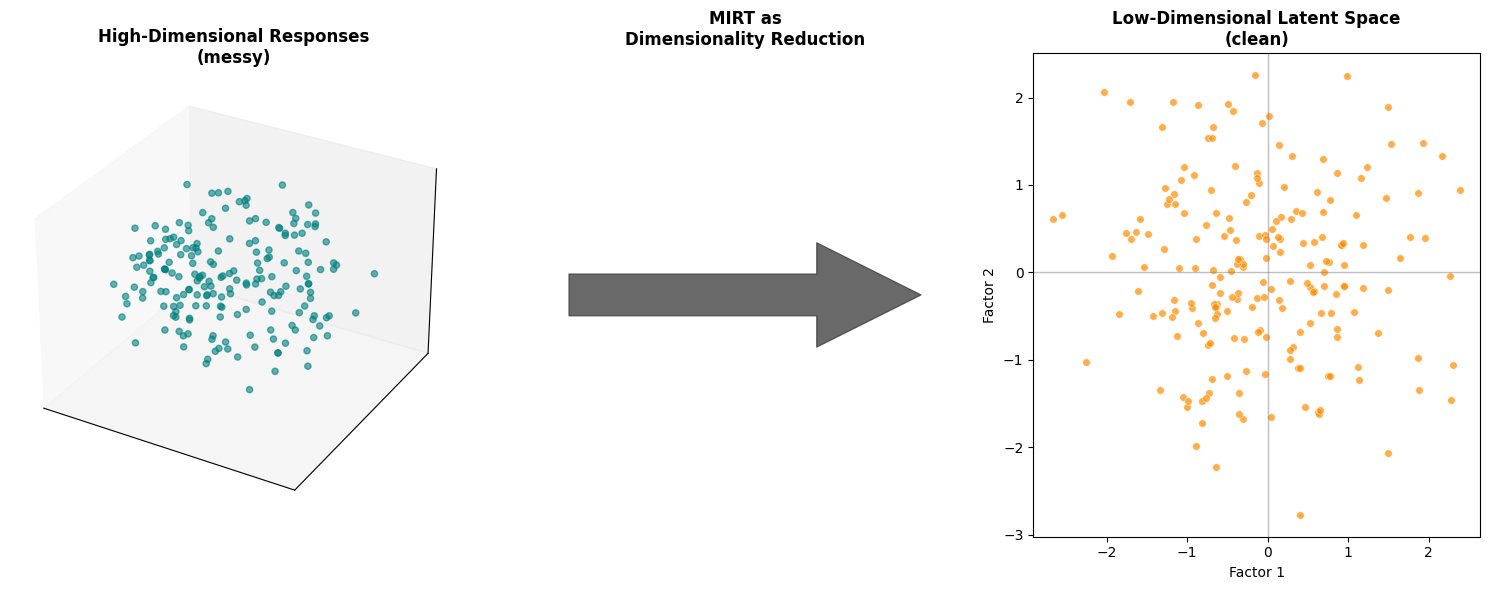

In [7]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ----------------------------
# Visualization
# ----------------------------
fig = plt.figure(figsize=(15,6))

# Before: messy 3D cloud (responses in PCA 3D)
pca3 = PCA(n_components=3)
pre3 = pca3.fit_transform(responses)

ax1 = fig.add_subplot(131, projection='3d')
ax1.scatter(pre3[:,0], pre3[:,1], pre3[:,2], c="teal", alpha=0.6, s=20)
ax1.set_title("High-Dimensional Responses\n(messy)", fontsize=12, weight="bold")
ax1.set_xticks([]); ax1.set_yticks([]); ax1.set_zticks([])

# Middle: funnel/arrow
ax2 = fig.add_subplot(132)
arrow = FancyArrowPatch((0.1,0.5), (0.9,0.5),
                        connectionstyle="arc3,rad=0.0",
                        arrowstyle='simple', mutation_scale=150,
                        color="#444", alpha=0.8)
ax2.add_patch(arrow)
ax2.axis("off")
ax2.set_title("MIRT as\nDimensionality Reduction", fontsize=12, weight="bold")

# After: 2D latent map
ax3 = fig.add_subplot(133)
ax3.scatter(post_coords[:,0], post_coords[:,1], c="darkorange", alpha=0.7, s=30, edgecolor="white", linewidth=0.5)
ax3.axhline(0, color="gray", lw=1, alpha=0.5)
ax3.axvline(0, color="gray", lw=1, alpha=0.5)
ax3.set_title("Low-Dimensional Latent Space\n(clean)", fontsize=12, weight="bold")
ax3.set_xlabel("Factor 1"); ax3.set_ylabel("Factor 2")

plt.tight_layout()
plt.show()


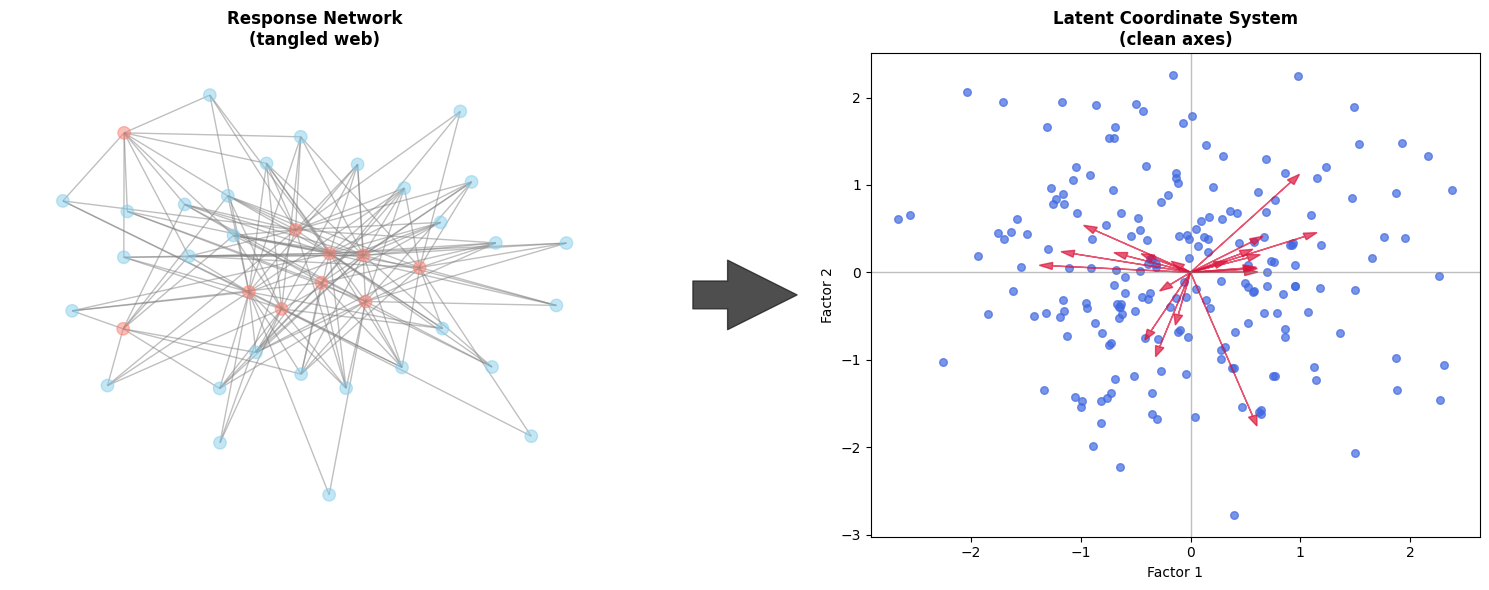

In [8]:
import networkx as nx

# ----------------------------
# Bipartite graph construction
# ----------------------------
G = nx.Graph()
examinees = [f"E{i}" for i in range(30)]   # subset for clarity
items = [f"I{j}" for j in range(10)]

G.add_nodes_from(examinees, bipartite=0)
G.add_nodes_from(items, bipartite=1)

# Add edges for positive responses
for i, e in enumerate(examinees):
    for j, it in enumerate(items):
        if responses[i,j] == 1:
            G.add_edge(e, it)

# ----------------------------
# Visualization
# ----------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 6), gridspec_kw={'width_ratios':[1,0.2,1]})

# Before: tangled bipartite network
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, ax=axes[0], node_size=80, 
        node_color=["skyblue" if n in examinees else "salmon" for n in G.nodes()],
        edge_color="gray", alpha=0.5, with_labels=False)
axes[0].set_title("Response Network\n(tangled web)", fontsize=12, weight="bold")

# Arrow
arrow = FancyArrowPatch((0.05,0.5), (0.95,0.5),
                        connectionstyle="arc3,rad=0.0",
                        arrowstyle='simple', mutation_scale=100,
                        color="#222", alpha=0.8)
axes[1].add_patch(arrow)
axes[1].axis("off")

# After: clean latent space
axes[2].scatter(post_coords[:,0], post_coords[:,1], c="royalblue", alpha=0.7, s=30, label="Examinees")
for j in range(len(a)):
    axes[2].arrow(0,0, a[j,0]*0.6, a[j,1]*0.6, 
                  head_width=0.08, color="crimson", alpha=0.7)
axes[2].axhline(0, color="gray", lw=1, alpha=0.5)
axes[2].axvline(0, color="gray", lw=1, alpha=0.5)
axes[2].set_title("Latent Coordinate System\n(clean axes)", fontsize=12, weight="bold")
axes[2].set_xlabel("Factor 1"); axes[2].set_ylabel("Factor 2")

plt.tight_layout()
plt.show()


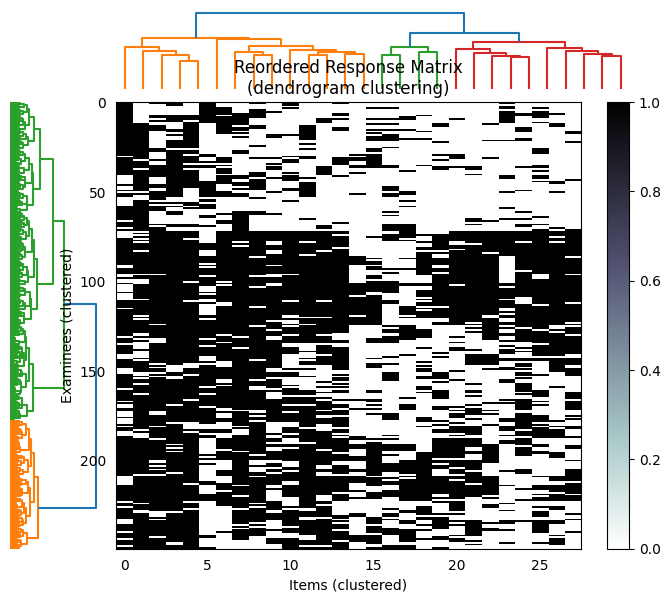

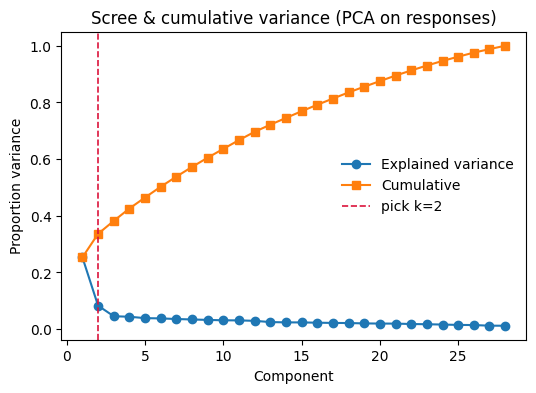

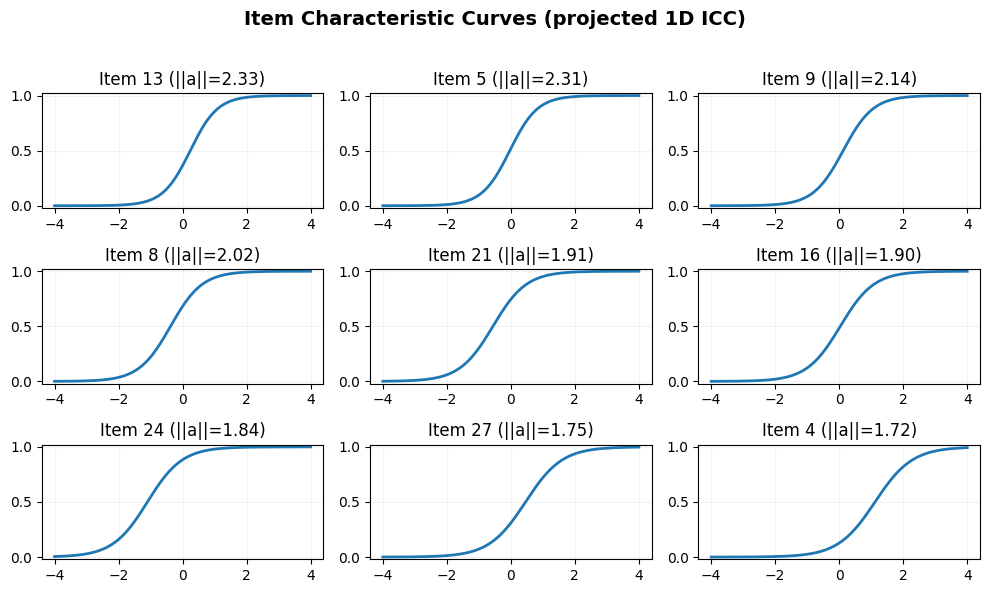

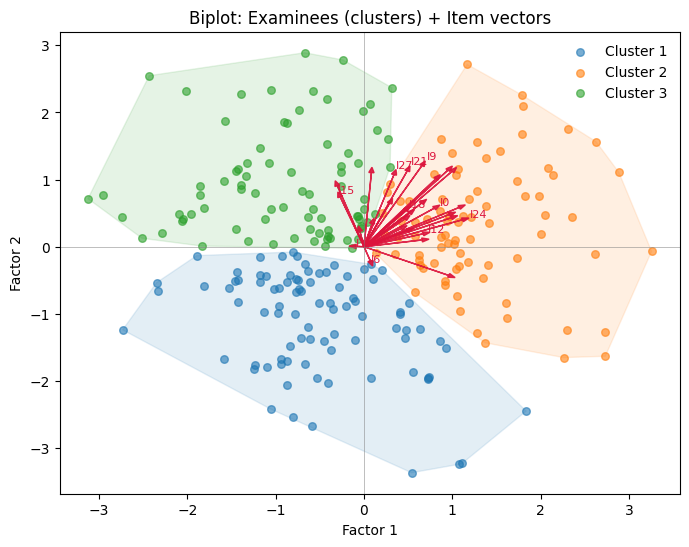

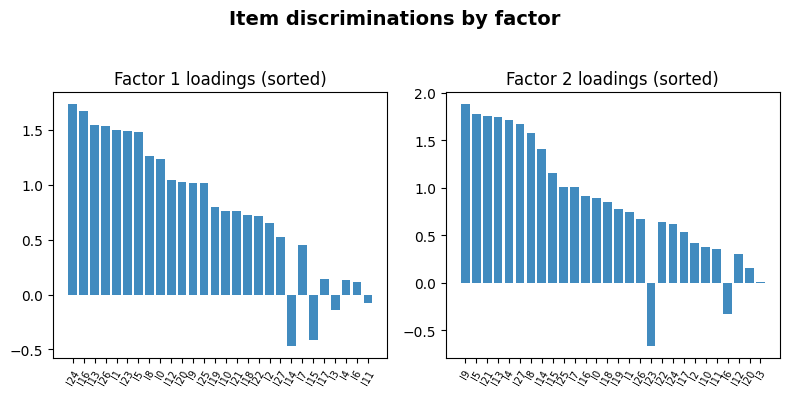

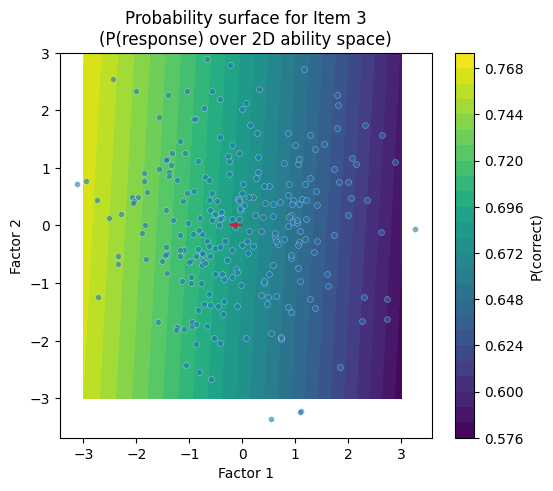

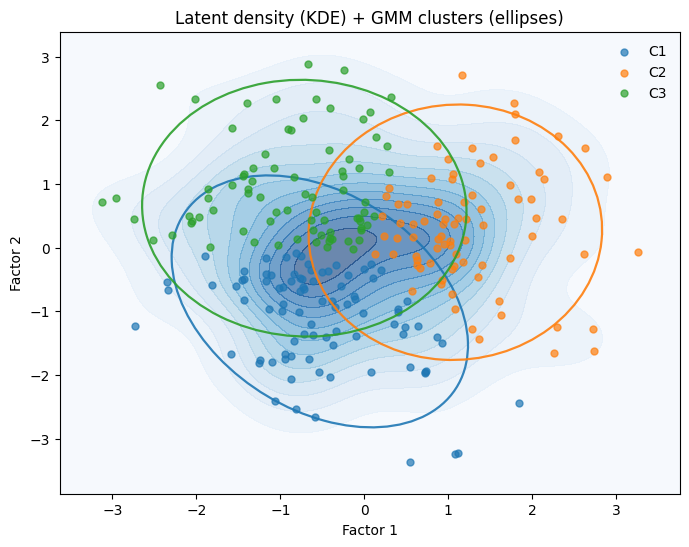

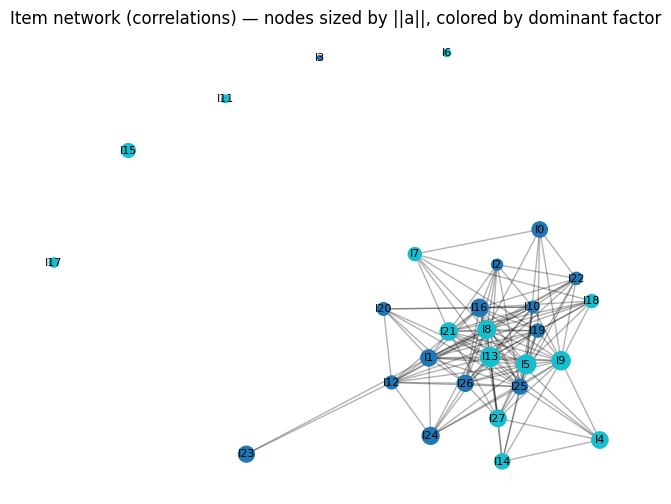

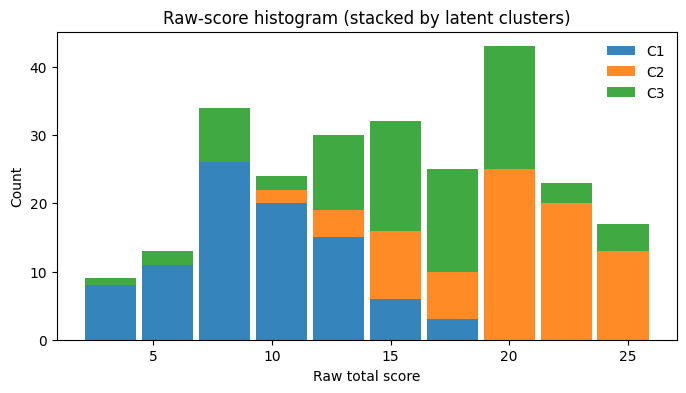

All demo figures produced. Replace synthetic arrays with your estimated theta,a,b,responses for production.


In [9]:
"""
MIRT visualization gallery
Replace synthetic 'theta, a, b, responses' with your estimated parameters/data.
Requires: numpy, matplotlib, sklearn, scipy, networkx (optional)
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Ellipse
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from scipy.cluster.hierarchy import linkage, dendrogram, leaves_list
from scipy.spatial import ConvexHull
from scipy.stats import gaussian_kde
import networkx as nx
import warnings
warnings.filterwarnings("ignore")

# ----------------------------
# Synthetic MIRT-like dataset
# ----------------------------
np.random.seed(0)
n_examinees, n_items, k_dim = 250, 28, 2

# "True" latent abilities (2D)
theta = np.random.normal(scale=1.2, size=(n_examinees, k_dim))

# Item discriminations (a) and difficulties (b)
# Use mostly positive discriminations for nicer arrows
a = np.random.normal(loc=0.9, scale=0.6, size=(n_items, k_dim))
b = np.random.normal(loc=0.0, scale=1.0, size=(n_items,))

def logistic(x):
    return 1.0 / (1.0 + np.exp(-x))

def irt_prob(theta, a, b):
    # theta: (N,k), a:(J,k), b:(J,)
    return logistic(theta @ a.T - b)

p = irt_prob(theta, a, b)
responses = (np.random.rand(*p.shape) < p).astype(int)  # binary matrix

# For visualization, pretend we "estimated" theta,a,b (here we use truth +/- noise)
theta_est = theta + np.random.normal(scale=0.05, size=theta.shape)
a_est = a + np.random.normal(scale=0.05, size=a.shape)
b_est = b + np.random.normal(scale=0.05, size=b.shape)


# ----------------------------
# Helpers
# ----------------------------
def save_or_show(fig, fname=None):
    if fname:
        fig.savefig(fname, bbox_inches='tight', dpi=300)
        print(f"Saved {fname}")
    else:
        plt.show()


# ----------------------------
# 1) Reordered heatmap + dendrogram
# ----------------------------
def plot_reordered_heatmap(resp, figsize=(8,7), vmax=None, fname=None):
    # Hierarchical clustering on examinees and items and reorder matrix
    # resp: N x J binary matrix
    Z_rows = linkage(resp, method='ward')
    Z_cols = linkage(resp.T, method='ward')
    row_order = leaves_list(Z_rows)
    col_order = leaves_list(Z_cols)
    resp_re = resp[row_order][:, col_order]

    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(2,2, width_ratios=[0.15,0.85], height_ratios=[0.15,0.85],
                          wspace=0.05, hspace=0.05)

    ax_dend_x = fig.add_subplot(gs[0,1])
    ax_dend_y = fig.add_subplot(gs[1,0])
    ax_img = fig.add_subplot(gs[1,1])

    dendrogram(Z_cols, ax=ax_dend_x, color_threshold=None, no_labels=True)
    ax_dend_x.axis('off')
    dendrogram(Z_rows, ax=ax_dend_y, orientation='right', color_threshold=None, no_labels=True)
    ax_dend_y.axis('off')

    im = ax_img.imshow(resp_re, aspect='auto', cmap='bone_r', interpolation='nearest', vmin=0, vmax=vmax)
    ax_img.set_xlabel("Items (clustered)")
    ax_img.set_ylabel("Examinees (clustered)")
    ax_img.set_title("Reordered Response Matrix\n(dendrogram clustering)")
    ax_img.tick_params(left=False, bottom=False)
    plt.colorbar(im, ax=ax_img, fraction=0.045)
    save_or_show(fig, fname)


# ----------------------------
# 2) Item Characteristic Curves (ICCs)
# ----------------------------
def plot_iccs(a_est, b_est, which_items=None, ncols=3, figsize=(10,6), fname=None):
    if which_items is None:
        # choose items with largest discrimination norm
        norms = np.linalg.norm(a_est, axis=1)
        which_items = np.argsort(-norms)[:9]  # top 9 discriminating items

    n = len(which_items)
    nrows = int(np.ceil(n / ncols))
    x = np.linspace(-4, 4, 300)
    fig, axs = plt.subplots(nrows, ncols, figsize=figsize, squeeze=False)
    for i, itm in enumerate(which_items):
        r, c = divmod(i, ncols)
        ax = axs[r][c]
        ai = a_est[itm]
        bi = b_est[itm]
        # project unidimensional ability along item direction
        slope = np.linalg.norm(ai)
        p_x = logistic(x * slope - bi)
        ax.plot(x, p_x, lw=2)
        ax.set_ylim(-0.02, 1.02)
        ax.set_title(f"Item {itm} (||a||={slope:.2f})")
        ax.grid(alpha=0.15)
    # hide empty subplots
    for j in range(i+1, nrows*ncols):
        r, c = divmod(j, ncols)
        axs[r][c].axis('off')
    fig.suptitle("Item Characteristic Curves (projected 1D ICC)", fontsize=14, weight='bold')
    plt.tight_layout(rect=[0,0,1,0.96])
    save_or_show(fig, fname)


# ----------------------------
# 3) Biplot: examinees + item vectors with convex hulls per cluster
# ----------------------------
def plot_biplot(theta_est, a_est, n_clusters=3, figsize=(8,6), fname=None):
    # cluster examinees for color
    gmm = GaussianMixture(n_components=n_clusters, random_state=0).fit(theta_est)
    labels = gmm.predict(theta_est)

    fig, ax = plt.subplots(figsize=figsize)
    cmap = plt.get_cmap('tab10')
    for k in range(n_clusters):
        mask = labels == k
        pts = theta_est[mask]
        ax.scatter(pts[:,0], pts[:,1], s=30, alpha=0.6, label=f"Cluster {k+1}", color=cmap(k))

        # convex hull for cluster
        if pts.shape[0] > 2:
            try:
                hull = ConvexHull(pts)
                poly = pts[hull.vertices]
                ax.fill(poly[:,0], poly[:,1], alpha=0.12, color=cmap(k))
            except Exception:
                pass

    # item vectors (scaled)
    scale = 1.5 / np.max(np.linalg.norm(a_est, axis=1))
    for j in range(a_est.shape[0]):
        ax.arrow(0, 0, a_est[j,0]*scale, a_est[j,1]*scale,
                 head_width=0.06, head_length=0.08, color='crimson', alpha=0.9)
        if j % 3 == 0:
            ax.text(a_est[j,0]*scale*1.08, a_est[j,1]*scale*1.08, f"I{j}", color='crimson', fontsize=8)

    ax.axhline(0, color='gray', linewidth=0.6, alpha=0.6)
    ax.axvline(0, color='gray', linewidth=0.6, alpha=0.6)
    ax.set_xlabel("Factor 1")
    ax.set_ylabel("Factor 2")
    ax.set_title("Biplot: Examinees (clusters) + Item vectors")
    ax.legend(frameon=False)
    save_or_show(fig, fname)


# ----------------------------
# 4) Factor loadings barplot (per-factor)
# ----------------------------
def plot_loadings_bar(a_est, figsize=(8,4), fname=None):
    # Show absolute values sorted for each factor
    fig, axs = plt.subplots(1, a_est.shape[1], figsize=figsize, squeeze=False)
    for f in range(a_est.shape[1]):
        ax = axs[0,f]
        vals = a_est[:,f]
        order = np.argsort(np.abs(vals))[::-1]
        ax.bar(np.arange(len(vals)), vals[order], alpha=0.85)
        ax.set_xticks(np.arange(len(vals)))
        ax.set_xticklabels([f"I{o}" for o in order], rotation=60, fontsize=7)
        ax.set_title(f"Factor {f+1} loadings (sorted)")
    fig.suptitle("Item discriminations by factor", fontsize=14, weight='bold')
    plt.tight_layout(rect=[0,0,1,0.95])
    save_or_show(fig, fname)


# ----------------------------
# 5) Probability surface (heatmap) for selected items in 2D latent space
# ----------------------------
def plot_item_prob_surface(a_est, b_est, item_idx=0, xrange=(-3,3), yrange=(-3,3), 
                           gridn=200, figsize=(6,5), fname=None):
    axv = np.linspace(xrange[0], xrange[1], gridn)
    ayv = np.linspace(yrange[0], yrange[1], gridn)
    X, Y = np.meshgrid(axv, ayv)
    # compute p(x,y) for this item
    a_i = a_est[item_idx]
    b_i = b_est[item_idx]
    XY = np.column_stack([X.ravel(), Y.ravel()])
    P = logistic(XY @ a_i - b_i).reshape(X.shape)

    fig, ax = plt.subplots(figsize=figsize)
    cf = ax.contourf(X, Y, P, levels=30, cmap='viridis')
    ax.scatter(theta_est[:,0], theta_est[:,1], s=18, alpha=0.6, edgecolor='white', linewidth=0.3)
    # item vector
    ax.arrow(0, 0, a_i[0]*0.8, a_i[1]*0.8, color='crimson', head_width=0.08, alpha=0.9)
    ax.set_title(f"Probability surface for Item {item_idx}\n(P(response) over 2D ability space)")
    ax.set_xlabel("Factor 1"); ax.set_ylabel("Factor 2")
    plt.colorbar(cf, ax=ax, label='P(correct)')
    save_or_show(fig, fname)


# ----------------------------
# 6) Latent KDE contours + GMM ellipses
# ----------------------------
def plot_latent_kde_and_gmm(theta_est, n_components=3, figsize=(8,6), fname=None):
    gmm = GaussianMixture(n_components=n_components, random_state=0).fit(theta_est)
    labels = gmm.predict(theta_est)

    # KDE for background
    xy = theta_est.T
    kde = gaussian_kde(xy)
    xmin, ymin = xy[0].min()-0.5, xy[1].min()-0.5
    xmax, ymax = xy[0].max()+0.5, xy[1].max()+0.5
    xx, yy = np.mgrid[xmin:xmax:200j, ymin:ymax:200j]
    grid_coords = np.vstack([xx.ravel(), yy.ravel()])
    z = kde(grid_coords).reshape(xx.shape)

    fig, ax = plt.subplots(figsize=figsize)
    ax.contourf(xx, yy, z, levels=15, cmap='Blues', alpha=0.6)
    cmap = plt.get_cmap('tab10')
    for k in range(n_components):
        mask = labels==k
        ax.scatter(theta_est[mask,0], theta_est[mask,1], s=25, alpha=0.7, color=cmap(k), label=f"C{k+1}")
        # draw GMM covariance ellipse
        mean = gmm.means_[k]
        cov = gmm.covariances_[k]
        if cov.shape == (2,2):
            vals, vecs = np.linalg.eigh(cov)
            angle = np.degrees(np.arctan2(vecs[1,0], vecs[0,0]))
            width, height = 2*np.sqrt(vals)
            ell = Ellipse(mean, width*2, height*2, angle=angle, edgecolor=cmap(k), facecolor='none', lw=1.6, alpha=0.9)
            ax.add_patch(ell)
    ax.set_title("Latent density (KDE) + GMM clusters (ellipses)")
    ax.set_xlabel("Factor 1"); ax.set_ylabel("Factor 2")
    ax.legend(frameon=False)
    save_or_show(fig, fname)


# ----------------------------
# 7) Scree plot (PCA on responses)
# ----------------------------
def plot_scree(resp, figsize=(6,4), pick_k=2, fname=None):
    pca = PCA().fit(resp)
    ev = pca.explained_variance_ratio_
    cum = np.cumsum(ev)
    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(np.arange(1, len(ev)+1), ev, '-o', label='Explained variance')
    ax.plot(np.arange(1, len(ev)+1), cum, '-s', label='Cumulative')
    ax.axvline(pick_k, color='crimson', lw=1.2, linestyle='--', label=f'pick k={pick_k}')
    ax.set_xlabel('Component')
    ax.set_ylabel('Proportion variance')
    ax.set_title('Scree & cumulative variance (PCA on responses)')
    ax.legend(frameon=False)
    save_or_show(fig, fname)


# ----------------------------
# 8) Item network by item-response correlations
# ----------------------------
def plot_item_network(resp, a_est, threshold=0.2, figsize=(8,6), fname=None):
    # compute item-item Pearson correlations
    corr = np.corrcoef(resp.T)
    J = corr.shape[0]
    G = nx.Graph()
    for j in range(J):
        G.add_node(j, size=np.linalg.norm(a_est[j]), factor_dir=np.argmax(np.abs(a_est[j])))

    # add edges above threshold
    for i in range(J):
        for j in range(i+1, J):
            w = corr[i,j]
            if abs(w) >= threshold:
                G.add_edge(i, j, weight=w)

    pos = nx.spring_layout(G, seed=0, k=0.6)
    sizes = np.array([G.nodes[n]['size'] for n in G.nodes()]) * 80
    colors = [G.nodes[n]['factor_dir'] for n in G.nodes()]

    fig, ax = plt.subplots(figsize=figsize)
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.3)
    nx.draw_networkx_nodes(G, pos, node_size=sizes, node_color=colors, cmap='tab10')
    nx.draw_networkx_labels(G, pos, {n: f"I{n}" for n in G.nodes()}, font_size=8)
    ax.set_title("Item network (correlations) — nodes sized by ||a||, colored by dominant factor")
    ax.axis('off')
    save_or_show(fig, fname)


# ----------------------------
# 9) Raw-score histogram -> latent cluster stacked bar (bridge)
# ----------------------------
def plot_rawscore_to_clusters(resp, theta_est, n_clusters=3, bins=10, figsize=(8,4), fname=None):
    totals = resp.sum(axis=1)
    gmm = GaussianMixture(n_components=n_clusters, random_state=0).fit(theta_est)
    labels = gmm.predict(theta_est)

    # create stacked histogram per cluster
    fig, ax = plt.subplots(figsize=figsize)
    counts_per_bin = []
    bin_edges = np.linspace(totals.min(), totals.max(), bins+1)
    for k in range(n_clusters):
        hist, _ = np.histogram(totals[labels==k], bins=bin_edges)
        counts_per_bin.append(hist)
    counts_per_bin = np.array(counts_per_bin)

    # stacked bar
    bottom = np.zeros(len(bin_edges)-1)
    x = 0.5*(bin_edges[:-1] + bin_edges[1:])
    cmap = plt.get_cmap('tab10')
    for k in range(n_clusters):
        ax.bar(x, counts_per_bin[k], width=(bin_edges[1]-bin_edges[0])*0.9, bottom=bottom, color=cmap(k), alpha=0.9, label=f"C{k+1}")
        bottom += counts_per_bin[k]
    ax.set_xlabel("Raw total score")
    ax.set_ylabel("Count")
    ax.set_title("Raw-score histogram (stacked by latent clusters)")
    ax.legend(frameon=False)
    save_or_show(fig, fname)


# ----------------------------
# Run / demo: create all figures
# ----------------------------
if __name__ == "__main__":
    # Replace these file names with None to simply show interactively instead of saving
    plot_reordered_heatmap(responses, fname=None)
    plot_scree(responses, pick_k=2, fname=None)
    plot_iccs(a_est, b_est, which_items=None, fname=None)
    plot_biplot(theta_est, a_est, n_clusters=3, fname=None)
    plot_loadings_bar(a_est, fname=None)
    plot_item_prob_surface(a_est, b_est, item_idx=3, fname=None)
    plot_latent_kde_and_gmm(theta_est, n_components=3, fname=None)
    try:
        plot_item_network(responses, a_est, threshold=0.25, fname=None)
    except Exception as e:
        print("Item network skipped (networkx/scipy issues?)", e)
    plot_rawscore_to_clusters(responses, theta_est, n_clusters=3, fname=None)

    print("All demo figures produced. Replace synthetic arrays with your estimated theta,a,b,responses for production.")


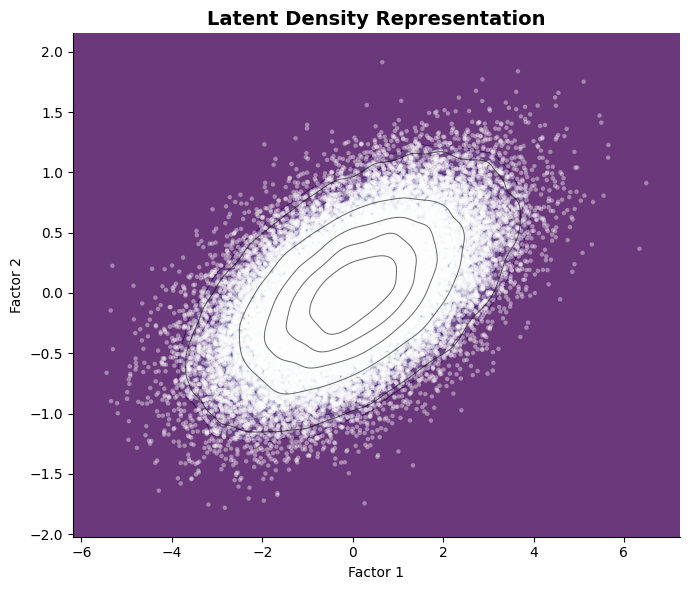

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_spd_matrix

# Synthetic latent space (2D)
np.random.seed(42)
n_examinees, n_items = 40000, 183
theta = np.random.multivariate_normal(mean=[0,0], cov=make_spd_matrix(2), size=n_examinees)
a = np.random.normal(size=(n_items, 2))  # item loadings

# ----------------------------
# Visualization
# ----------------------------
fig, ax = plt.subplots(figsize=(7,6))

# KDE density background
sns.kdeplot(
    x=theta[:,0], y=theta[:,1],
    fill=True, cmap="viridis", levels=30, thresh=0, alpha=0.8,
    ax=ax
)

# Contour lines for extra clarity
sns.kdeplot(
    x=theta[:,0], y=theta[:,1],
    colors="black", levels=6, linewidths=0.7, alpha=0.6,
    ax=ax
)

# Scatter of examinees
ax.scatter(theta[:,0], theta[:,1], c="white", s=10, alpha=0.4, edgecolor="none")

# Items as arrows
# for i in range(n_items):
#     ax.arrow(0, 0, a[i,0]*0.8, a[i,1]*0.8,
#              head_width=0.1, color="crimson", alpha=0.8, lw=1.2)

# Styling
ax.set_title("Latent Density Representation", fontsize=14, weight="bold")
ax.set_xlabel("Factor 1")
ax.set_ylabel("Factor 2")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()
